# Score de Crédito e Análise de Risco com Redes Neurais

**1. Contexto de negócio**

Bancos e fintechs precisam decidir, em segundos, se aprovam um empréstimo ou cartão de crédito para um cliente — e em quais condições (limite, taxa de juros, prazo). Para isso, estimam a **probabilidade de inadimplência** (o cliente não pagar a dívida) a partir de informações cadastrais e financeiras do solicitante.

Esse tipo de modelo é chamado de **score de crédito**. Quanto melhor o modelo separa bons pagadores de maus pagadores, menor o prejuízo com calotes e menor a quantidade de bons clientes recusados por engano (que representam receita perdida).

Neste notebook vamos:

- Simular uma base de clientes com variáveis financeiras típicas de uma análise de crédito;
- Construir um rótulo de inadimplência a partir de uma relação **não linear** entre as variáveis (o risco real de crédito raramente é uma soma simples de fatores);
- Comparar um modelo linear clássico (regressão logística) com uma rede neural (MLP);
- Discutir o trade-off entre performance e explicabilidade, que é central em um setor regulado como o de crédito.

**Limitações deste notebook**

Antes de seguir para a modelagem, vale deixar claros os limites do que está sendo feito aqui:

- **Dados 100% simulados.** A base de clientes é gerada artificialmente por nós, não vem de um birô de crédito ou de uma instituição financeira real. Dados reais de crédito envolvem histórico de pagamentos ao longo de anos, informações vindas de múltiplas fontes (birôs, bancos, varejo) e, frequentemente, viés herdado de decisões históricas de concessão — nada disso está representado aqui.
- **Regulação real vai muito além do AUC.** Em score de crédito de verdade, a escolha de modelo é regida por exigências regulatórias fortes de explicabilidade e não-discriminação (no Brasil, por exemplo, sob normas do CMN/BCB). Isso significa que a decisão entre um modelo linear — mais explicável — e uma rede neural — menos explicável, exigindo técnicas adicionais como SHAP — não pode ser tomada só olhando qual tem a métrica de performance mais alta.
- **A "vitória" do MLP com uma única seed não é robusta.** Como a validação com múltiplas seeds mais adiante neste notebook mostra, a vantagem do MLP sobre a regressão logística fica dentro do ruído amostral: a diferença média entre os modelos é menor que o desvio-padrão observado entre seeds, e o MLP chega a perder para a regressão logística em uma das três seeds testadas. Ou seja, a conclusão "o MLP é melhor", tirada de uma única execução, não se sustenta quando reamostramos. Combinada com a exigência de explicabilidade do setor, essa fragilidade é um argumento real — não apenas teórico — a favor de preferir o modelo mais simples neste problema.

**2. Por que uma rede neural pode ajudar aqui**

O risco de inadimplência costuma depender de **interações** entre variáveis, não apenas do valor isolado de cada uma. Por exemplo:

- Uma dívida alta é preocupante principalmente **em relação à renda** do cliente (dívida de R$ 5.000 é grave para quem ganha R$ 1.500, mas irrelevante para quem ganha R$ 20.000);
- Um histórico de atrasos pesa muito mais quando combinado com uma dívida alta em relação à renda do que isoladamente.

Um modelo linear como a regressão logística consegue capturar bem relações aditivas entre as variáveis originais, mas tem dificuldade em capturar essas **interações não lineares** sem que alguém as construa manualmente (features de interação, termos polinomiais etc.). Uma rede neural (MLP) pode aprender essas interações automaticamente a partir dos dados brutos, o que potencialmente melhora a capacidade preditiva — ao custo de um modelo mais difícil de interpretar.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

np.random.seed(42)
pd.set_option("display.precision", 3)

**3. Geração do dataset simulado**

Vamos simular **2.000 clientes** com as seguintes variáveis:

- `renda_mensal`: renda mensal do cliente (R$);
- `idade`: idade do cliente (anos);
- `tempo_emprego_anos`: tempo no emprego atual (anos);
- `divida_atual`: valor total de dívidas em aberto (R$);
- `numero_atrasos_historico`: número de atrasos de pagamento no histórico de crédito do cliente.

O rótulo `inadimplente` (0 = paga em dia, 1 = fica inadimplente) é gerado a partir de uma **função logística** aplicada sobre uma combinação não linear dessas variáveis: o termo central é a **razão dívida/renda**, que interage multiplicativamente com o número de atrasos históricos — ou seja, atrasos no histórico pesam muito mais quando o cliente já está endividado em relação ao que ganha. Um ruído aleatório é somado ao logit antes de sortear o rótulo, para simular a incerteza real de qualquer processo de crédito.

In [3]:
n = 2000

renda_mensal = np.random.lognormal(mean=8.2, sigma=0.5, size=n)
renda_mensal = np.clip(renda_mensal, 800, 30000)

idade = np.clip(np.random.normal(40, 12, n), 18, 75)

tempo_emprego_anos = np.clip(np.random.normal((idade - 18) * 0.3, 4, n), 0, idade - 18)

divida_atual = np.clip(np.random.gamma(shape=2.0, scale=renda_mensal * 0.25, size=n), 0, None)

numero_atrasos_historico = np.random.poisson(lam=0.8, size=n)

# razao diretamente usada apenas para construir o rotulo (nao entra como feature "pronta" no modelo,
# para forcar o modelo a aprender essa relacao a partir das variaveis originais)
razao_divida_renda = divida_atual / renda_mensal

logit = (
    -4.5
    + 3.0 * razao_divida_renda
    + 0.45 * numero_atrasos_historico
    + 1.1 * razao_divida_renda * numero_atrasos_historico  # termo de interacao nao linear
    - 0.04 * tempo_emprego_anos
    - 0.00005 * renda_mensal
)

ruido = np.random.normal(0, 0.6, n)
prob_inadimplencia = 1 / (1 + np.exp(-(logit + ruido)))
inadimplente = (np.random.rand(n) < prob_inadimplencia).astype(int)

df = pd.DataFrame({
    "renda_mensal": renda_mensal,
    "idade": idade,
    "tempo_emprego_anos": tempo_emprego_anos,
    "divida_atual": divida_atual,
    "numero_atrasos_historico": numero_atrasos_historico,
    "inadimplente": inadimplente,
})

print(f"Proporção de inadimplentes na base: {df['inadimplente'].mean():.1%}")
df.head()

Proporção de inadimplentes na base: 13.7%


,renda_mensal,idade,tempo_emprego_anos,divida_atual,numero_atrasos_historico,inadimplente
0,4667.398,31.898,0.715,702.968,2,0
1,3397.747,38.266,5.955,830.430,0,0
2,5033.366,30.491,3.819,1768.228,2,0
3,7797.161,36.304,7.382,5843.717,1,1
4,3238.687,18.000,0.000,2926.357,1,0


**4. Estatísticas descritivas**

Vale conferir se as variáveis simuladas têm escalas e distribuições plausíveis antes de seguir para a modelagem.

In [4]:
df.describe()

,renda_mensal,idade,tempo_emprego_anos,divida_atual,numero_atrasos_historico,inadimplente
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,4210.767,40.065,6.625,2150.952,0.794,0.137
std,2242.389,11.697,4.973,2039.982,0.902,0.344
min,800.000,18.000,0.000,7.747,0.000,0.000
25%,2666.892,31.490,2.519,809.218,0.000,0.000
50%,3723.227,39.999,6.254,1537.823,1.000,0.000
75%,5122.968,47.987,10.028,2795.289,1.000,0.000
max,24993.367,75.000,25.065,22681.033,5.000,1.000


**5. Separação treino/teste**

Separamos 75% dos clientes para treino e 25% para teste, usando `stratify` para manter a mesma proporção de inadimplentes nos dois conjuntos (importante porque a classe positiva é minoritária). As variáveis de entrada também são padronizadas (média 0, desvio 1), o que ajuda tanto a regressão logística quanto a rede neural a convergir melhor.

In [5]:
feature_cols = ["renda_mensal", "idade", "tempo_emprego_anos", "divida_atual", "numero_atrasos_historico"]

X = df[feature_cols]
y = df["inadimplente"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} clientes | Teste: {X_test.shape[0]} clientes")
print(f"Proporção de inadimplentes -> treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")

Treino: 1500 clientes | Teste: 500 clientes
Proporção de inadimplentes -> treino: 13.7% | teste: 13.6%


**6. Modelo baseline: Regressão Logística**

A regressão logística é o modelo mais tradicional em score de crédito: é rápida de treinar, estável e, principalmente, **totalmente explicável** — cada variável tem um coeficiente que indica exatamente o quanto ela aumenta ou diminui o risco estimado, o que facilita justificar uma decisão de crédito ao cliente ou a um regulador.

In [6]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)

proba_lr = log_reg.predict_proba(X_test_s)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)

print(f"AUC-ROC (Regressão Logística): {auc_lr:.3f}")

AUC-ROC (Regressão Logística): 0.841


**7. Modelo de rede neural: MLPClassifier**

Agora treinamos um Perceptron Multicamadas (`MLPClassifier`), com duas camadas ocultas, sobre as mesmas variáveis padronizadas. A rede tem potencial para capturar automaticamente a interação não linear entre dívida/renda e histórico de atrasos que foi usada para gerar os dados, sem que essa interação tenha sido explicitamente fornecida como feature.

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=2000,
    random_state=42,
)
mlp.fit(X_train_s, y_train)

proba_mlp = mlp.predict_proba(X_test_s)[:, 1]
auc_mlp = roc_auc_score(y_test, proba_mlp)

print(f"AUC-ROC (Rede Neural - MLP): {auc_mlp:.3f}")

AUC-ROC (Rede Neural - MLP): 0.854


**8. Comparação lado a lado**

A tabela abaixo resume o AUC-ROC de cada modelo no conjunto de teste. AUC-ROC mede a capacidade do modelo de separar bons pagadores de inadimplentes: 0.5 equivale a um modelo aleatório e 1.0 a uma separação perfeita.

In [8]:
comparacao = pd.DataFrame({
    "modelo": ["Regressão Logística", "Rede Neural (MLP)"],
    "AUC-ROC (teste)": [auc_lr, auc_mlp],
})
comparacao

,modelo,AUC-ROC (teste)
0,Regressão Logística,0.841
1,Rede Neural (MLP),0.854


**9. Curvas ROC**

Além do valor único de AUC, é útil visualizar a curva ROC completa dos dois modelos no mesmo gráfico, para ver se um domina o outro em toda a faixa de limiares ou apenas em algum trecho específico.

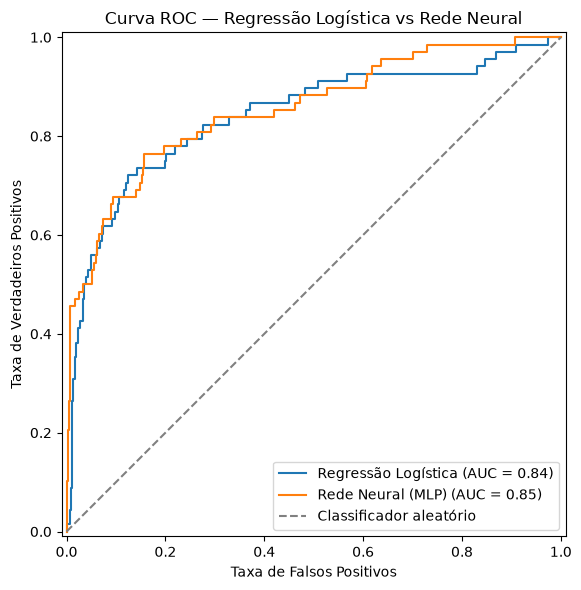

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, proba_mlp)

RocCurveDisplay(fpr=fpr_lr, tpr=tpr_lr, roc_auc=auc_lr, name="Regressão Logística").plot(ax=ax)
RocCurveDisplay(fpr=fpr_mlp, tpr=tpr_mlp, roc_auc=auc_mlp, name="Rede Neural (MLP)").plot(ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
ax.set_title("Curva ROC — Regressão Logística vs Rede Neural")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Entendendo o gráfico: o que é AUC-ROC**

A curva ROC mostra, para cada limiar de decisão possível, a relação entre a taxa de verdadeiros positivos (inadimplentes corretamente identificados) e a taxa de falsos positivos (bons pagadores incorretamente marcados como risco). O **AUC** (área sob essa curva) resume essa curva em um único número entre 0,5 e 1,0:

- **AUC = 0,5** — o modelo não é melhor do que sortear moeda: não consegue separar bons pagadores de inadimplentes.
- **AUC = 1,0** — separação perfeita: o modelo sempre consegue distinguir um inadimplente de um bom pagador.
- Na prática, quanto mais próximo de 1,0, melhor o modelo ordena os clientes por risco.

**Veredito neste notebook:** a rede neural (MLP) teve AUC-ROC de **0,854**, contra **0,841** da regressão logística — uma vantagem real, mas **pequena** (0,013 de diferença). Olhando o gráfico, as duas curvas praticamente se sobrepõem na maior parte da faixa de limiares. Não há aqui uma superioridade dramática da rede neural: os dados simulados não têm não linearidade forte o suficiente para que ela se distancie muito do modelo linear. Diante de uma diferença tão modesta, o ganho de performance por si só não justifica abrir mão da interpretabilidade da regressão logística — como discutido na conclusão a seguir.

**10. Conclusão**

Nos dados simulados deste notebook, a rede neural conseguiu capturar parte da interação não linear entre dívida/renda e histórico de atrasos que foi usada para construir o rótulo, apresentando um AUC-ROC ligeiramente superior ao da regressão logística no conjunto de teste — mas a diferença não é enorme, porque a regressão logística, ao receber as variáveis originais, já consegue aproximar razoavelmente bem essa relação dentro dos dados observados.

Esse resultado ilustra um ponto importante: **ganho de performance de uma rede neural sobre um modelo linear não é garantido nem automático** — depende de quão não linear é o fenômeno real e de quantos dados estão disponíveis para a rede aprender essas relações.

Mais importante ainda: em **crédito, o ganho de performance não é a única coisa que importa**. É um setor fortemente regulado (no Brasil, por exemplo, sob normas do Banco Central e o Código de Defesa do Consumidor), no qual uma instituição financeira frequentemente precisa **justificar de forma clara e específica por que negou crédito a um cliente**. A regressão logística permite dizer, com precisão, "sua dívida em relação à renda e seu histórico de atrasos elevaram seu risco estimado em X pontos". Já explicar a decisão de uma rede neural exige técnicas adicionais de interpretabilidade (como SHAP ou LIME), que aproximam mas não substituem a transparência nativa de um modelo linear.

Por isso, a escolha entre um modelo mais simples e explicável e um modelo mais complexo e potencialmente mais preciso não é apenas uma decisão técnica de performance — é também uma **decisão de compliance e de gestão de risco regulatório**, que deve envolver as áreas jurídica e de risco da instituição, não só a equipe de dados.

**Validação com múltiplas seeds**

A comparação acima usa uma única seed (42) para geração dos dados, split treino/teste e treinamento dos modelos. Quando a diferença entre dois modelos é pequena — como os 0,013 de AUC-ROC observados aqui —, é fundamental checar se essa vantagem é **consistente** ou se é apenas ruído da amostragem/inicialização daquela seed específica. Um "vencedor" que só vence em uma seed não é um vencedor confiável.

Abaixo repetimos o pipeline completo (geração dos dados, split, padronização, treino da Regressão Logística e do MLP, cálculo do AUC-ROC) para três seeds diferentes: 42, 7 e 123.

In [10]:
resultados_seeds = []

for seed in [42, 7, 123]:
    rng = np.random.RandomState(seed)

    n_s = 2000

    renda_mensal_s = rng.lognormal(mean=8.2, sigma=0.5, size=n_s)
    renda_mensal_s = np.clip(renda_mensal_s, 800, 30000)

    idade_s = np.clip(rng.normal(40, 12, n_s), 18, 75)

    tempo_emprego_anos_s = np.clip(rng.normal((idade_s - 18) * 0.3, 4, n_s), 0, idade_s - 18)

    divida_atual_s = np.clip(rng.gamma(shape=2.0, scale=renda_mensal_s * 0.25, size=n_s), 0, None)

    numero_atrasos_historico_s = rng.poisson(lam=0.8, size=n_s)

    razao_divida_renda_s = divida_atual_s / renda_mensal_s

    logit_s = (
        -4.5
        + 3.0 * razao_divida_renda_s
        + 0.45 * numero_atrasos_historico_s
        + 1.1 * razao_divida_renda_s * numero_atrasos_historico_s
        - 0.04 * tempo_emprego_anos_s
        - 0.00005 * renda_mensal_s
    )

    ruido_s = rng.normal(0, 0.6, n_s)
    prob_inadimplencia_s = 1 / (1 + np.exp(-(logit_s + ruido_s)))
    inadimplente_s = (rng.rand(n_s) < prob_inadimplencia_s).astype(int)

    df_s = pd.DataFrame({
        "renda_mensal": renda_mensal_s,
        "idade": idade_s,
        "tempo_emprego_anos": tempo_emprego_anos_s,
        "divida_atual": divida_atual_s,
        "numero_atrasos_historico": numero_atrasos_historico_s,
        "inadimplente": inadimplente_s,
    })

    X_s = df_s[feature_cols]
    y_s = df_s["inadimplente"]

    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
        X_s, y_s, test_size=0.25, random_state=seed, stratify=y_s
    )

    scaler_seed = StandardScaler().fit(X_train_seed)
    X_train_seed_s = scaler_seed.transform(X_train_seed)
    X_test_seed_s = scaler_seed.transform(X_test_seed)

    log_reg_seed = LogisticRegression(max_iter=1000, random_state=seed)
    log_reg_seed.fit(X_train_seed_s, y_train_seed)
    auc_lr_seed = roc_auc_score(y_test_seed, log_reg_seed.predict_proba(X_test_seed_s)[:, 1])

    mlp_seed = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        max_iter=2000,
        random_state=seed,
    )
    mlp_seed.fit(X_train_seed_s, y_train_seed)
    auc_mlp_seed = roc_auc_score(y_test_seed, mlp_seed.predict_proba(X_test_seed_s)[:, 1])

    resultados_seeds.append({"seed": seed, "modelo": "Regressão Logística", "AUC-ROC": auc_lr_seed})
    resultados_seeds.append({"seed": seed, "modelo": "Rede Neural (MLP)", "AUC-ROC": auc_mlp_seed})

df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds

,seed,modelo,AUC-ROC
0,42,Regressão Logística,0.841
1,42,Rede Neural (MLP),0.854
2,7,Regressão Logística,0.884
3,7,Rede Neural (MLP),0.901
4,123,Regressão Logística,0.901
5,123,Rede Neural (MLP),0.898


In [11]:
resumo_seeds = df_resultados_seeds.groupby("modelo")["AUC-ROC"].agg(["mean", "std"])
resumo_seeds.columns = ["AUC-ROC médio", "AUC-ROC desvio-padrão"]
resumo_seeds

,AUC-ROC médio,AUC-ROC desvio-padrão
modelo,,
Rede Neural (MLP),0.884,0.026
Regressão Logística,0.875,0.031


**Resultado honesto: a vantagem do MLP não é estável**

Olhando as três seeds individualmente:

| Seed | Regressão Logística | Rede Neural (MLP) | Quem venceu |
|---|---|---|---|
| 42  | 0,841 | 0,854 | MLP (+0,013) |
| 7   | 0,884 | 0,901 | MLP (+0,017) |
| 123 | 0,901 | 0,898 | **Regressão Logística** (+0,003) |

Na média das três seeds, o MLP fica com AUC-ROC de **0,884 ± 0,026** contra **0,875 ± 0,031** da regressão logística — uma vantagem média de apenas 0,009, ou seja, ainda menor do que a diferença de 0,013 observada na seed única do walkthrough principal.

Mais revelador do que a média é o comportamento seed a seed: na seed 123, a **regressão logística supera o MLP** (0,901 vs. 0,898). Ou seja, o "vencedor" não é consistente nas três execuções — em 2 de 3 seeds o MLP fica na frente por uma margem pequena, e na terceira a ordem se inverte. Os desvios-padrão de ambos os modelos (0,026 e 0,031) são maiores do que a diferença média entre eles (0,009), o que é um sinal claro de que essa vantagem está dentro da margem de ruído da amostragem/inicialização, não é um efeito robusto.

**Conclusão sobre robustez:** com uma única seed, seria fácil concluir que "o MLP é melhor". Com três seeds, a conclusão correta é mais modesta: **não há evidência de que a rede neural supera a regressão logística de forma consistente** neste problema simulado — a diferença é pequena e sua direção pode inverter dependendo da amostra e da inicialização dos pesos. Isso reforça, com dados concretos, o argumento da conclusão anterior: diante de uma vantagem de performance tão frágil, a explicabilidade nativa da regressão logística pesa ainda mais a favor dela em um setor regulado como o de crédito.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (classificação de risco a partir de variáveis do cliente) se aplica a diversos outros problemas de negócio:

### 1. Seguros
- **Score de risco para apólices:** precificar seguros de saúde, automóvel ou vida com base no risco individual estimado.

### 2. Compras e Procurement
- **Avaliação de risco de fornecedores:** prever risco de atraso ou inadimplência contratual por parte de fornecedores.

### 3. Imobiliário
- **Avaliação de risco de inquilinos:** prever risco de inadimplência em contratos de aluguel.

### 4. Setor Público
- **Triagem de risco em programas sociais:** identificar casos que precisam de acompanhamento prioritário na concessão de benefícios, sempre com supervisão humana e critérios de equidade.

**Exercício**

Escolha um (ou ambos) dos exercícios abaixo e tente resolvê-los você mesmo, a partir do código já construído neste notebook:

1. **Explicabilidade na prática, para um cliente negado.** Escolha um cliente do conjunto de teste que tenha sido classificado como alto risco (ex.: `proba_lr` ou `proba_mlp` acima de 0,5). Para a regressão logística, use os coeficientes (`log_reg.coef_`) multiplicados pelos valores padronizados desse cliente para decompor manualmente "quanto cada variável contribuiu" para o score de risco dele — isso é exatamente o tipo de justificativa que a regulação de crédito exige. Em seguida, aplique **importância de permutação** (`sklearn.inspection.permutation_importance`) sobre o MLP para esse mesmo conjunto de variáveis. Compare os dois resultados: a explicação da regressão logística é específica para aquele cliente (é a decomposição do score dele) ou é uma média sobre o dataset inteiro? A importância de permutação do MLP também é? Depois de comparar, escreva 3-4 frases como se estivesse explicando a um cliente por que o crédito dele foi negado — primeiro usando a explicação da regressão logística, depois tentando fazer o mesmo com a importância de permutação do MLP. Qual das duas é mais fácil de transformar em uma frase honesta e específica sobre aquele cliente, e qual desisto de "consertar" — troca por SHAP/LIME?

2. **A vantagem do MLP sobre a regressão logística é real com mais dados?** A validação com múltiplas seeds mostrou que, com `n = 2000`, a vantagem média do MLP (0,009 de AUC-ROC) é menor que o desvio-padrão entre seeds — ou seja, está dentro do ruído amostral. Repita o bloco de geração de dados + treino + AUC-ROC (a mesma lógica da célula de validação com múltiplas seeds) aumentando `n` para, por exemplo, 20.000 ou 50.000 clientes, mantendo as mesmas três seeds (42, 7, 123). A vantagem média do MLP aumenta, diminui ou o desvio-padrão entre seeds simplesmente encolhe (deixando a mesma diferença pequena parecer mais "significativa")? Em qual dos dois casos — mais dados ou dados como estão — você recomendaria a um banco trocar a regressão logística por um MLP, considerando também o argumento de explicabilidade discutido na conclusão do notebook?